In [1]:
import pm4py
import pandas as pd
from pm4py.visualization.footprints import visualizer as fp_visualizer
from pm4py.algo.discovery.footprints import algorithm as footprints_discovery
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator

In [2]:
log = pm4py.read_xes("../data/samples/clean_sample.xes.gz")

/Users/felixhauptmann/ProM-Assignment-Group-C/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/5000 [00:00<?, ?it/s]

In [3]:
log_noised = pm4py.read_xes("../data/samples/noised_sample.xes.gz")

parsing log, completed traces ::   0%|          | 0/5000 [00:00<?, ?it/s]

In [4]:
log_recovered = pm4py.read_xes("../data/samples/recovered_sample.xes.gz")

parsing log, completed traces ::   0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
df = pm4py.convert_to_dataframe(log)
df_noised = pm4py.convert_to_dataframe(log_noised)
df_recovered = pm4py.convert_to_dataframe(log_recovered)

In [6]:
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
dfg_noised, start_activities_noised, end_activities_noised = pm4py.discover_dfg(log_noised)
dfg_recovered, start_activities_recovered, end_activities_recovered = pm4py.discover_dfg(log_recovered)

## a) Footprint Matrix

### 1. Clean log

In [7]:
footprints = footprints_discovery.apply(log)

In [8]:
footprints["sequence"]

{('A_Accepted', 'O_Create Offer'),
 ('A_Complete', 'A_Cancelled'),
 ('A_Complete', 'A_Denied'),
 ('A_Complete', 'O_Cancelled'),
 ('A_Complete', 'O_Create Offer'),
 ('A_Complete', 'O_Sent (mail and online)'),
 ('A_Complete', 'W_Shortened completion '),
 ('A_Concept', 'A_Accepted'),
 ('A_Concept', 'W_Shortened completion '),
 ('A_Create Application', 'A_Concept'),
 ('A_Create Application', 'A_Submitted'),
 ('A_Create Application', 'W_Complete application'),
 ('A_Denied', 'O_Refused'),
 ('A_Incomplete', 'O_Accepted'),
 ('A_Incomplete', 'O_Returned'),
 ('A_Pending', 'W_Call incomplete files'),
 ('A_Pending', 'W_Validate application'),
 ('A_Submitted', 'W_Handle leads'),
 ('A_Validating', 'A_Denied'),
 ('A_Validating', 'O_Accepted'),
 ('A_Validating', 'O_Returned'),
 ('O_Accepted', 'A_Pending'),
 ('O_Cancelled', 'A_Denied'),
 ('O_Cancelled', 'O_Create Offer'),
 ('O_Cancelled', 'O_Returned'),
 ('O_Created', 'A_Cancelled'),
 ('O_Created', 'A_Denied'),
 ('O_Created', 'O_Cancelled'),
 ('O_Creat

In [9]:
footprints["parallel"]

{('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Validate application'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Concept', 'W_Complete application'),
 ('A_Denied', 'W_Call after offers'),
 ('A_Denied', 'W_Call incomplete files'),
 ('A_Denied', 'W_Complete application'),
 ('A_Denied', 'W_Validate application'),
 ('A_Incomplete', 'W_Call incomplete files'),
 ('A_Validating', 'W_Validate application'),
 ('O_Cancelled', 'A_Cancelled'),
 ('O_Cancelled', 'O_Cancelled'),
 ('O_Cancelled', 'O_Sent (mail and online)'),
 ('O_Cancelled', 'O_Sent (online only)'),
 ('O_Cancelled', 'W_Call after offers'),
 ('O_Cancelled', 'W_Call incomplete files'),
 ('O_Cancelled', 'W_Complete application'),
 ('O_Cancelled', 'W_Validate application'),
 ('O_Create Offer', 'O_Created'),
 ('O_Crea

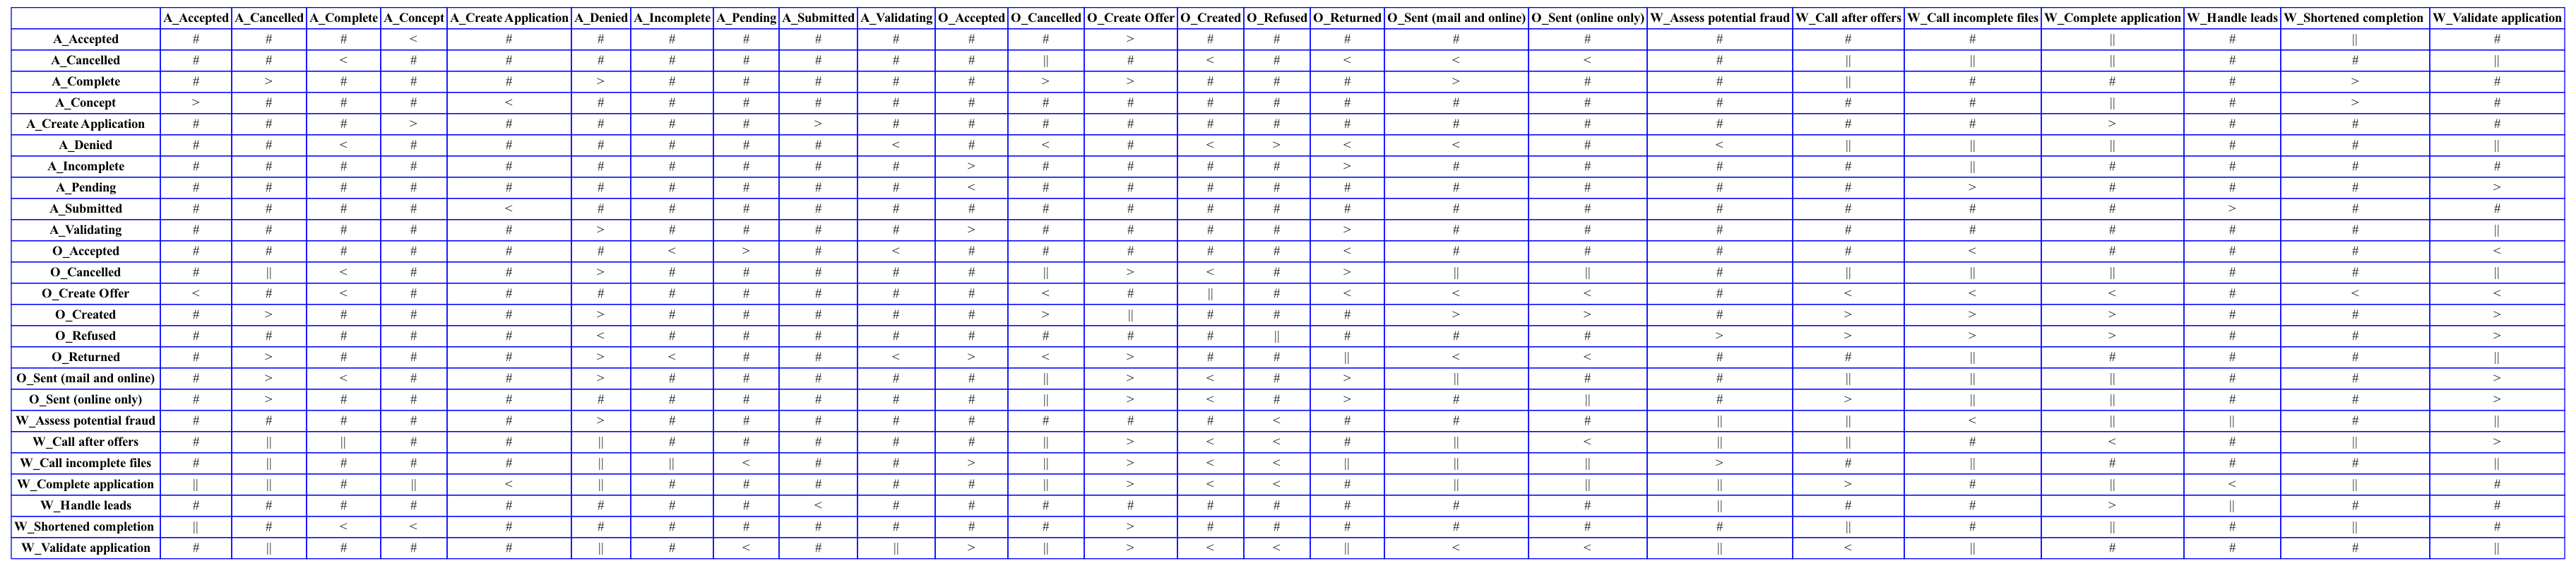

'../data/milestone2/footprints.svg'

In [10]:
gviz_footprints = fp_visualizer.apply(footprints)
fp_visualizer.view(gviz_footprints)
gviz_footprints.format = "svg"
gviz_footprints.render(
    filename="../data/milestone2/footprints",
    cleanup=True
)

#### Specific Trace

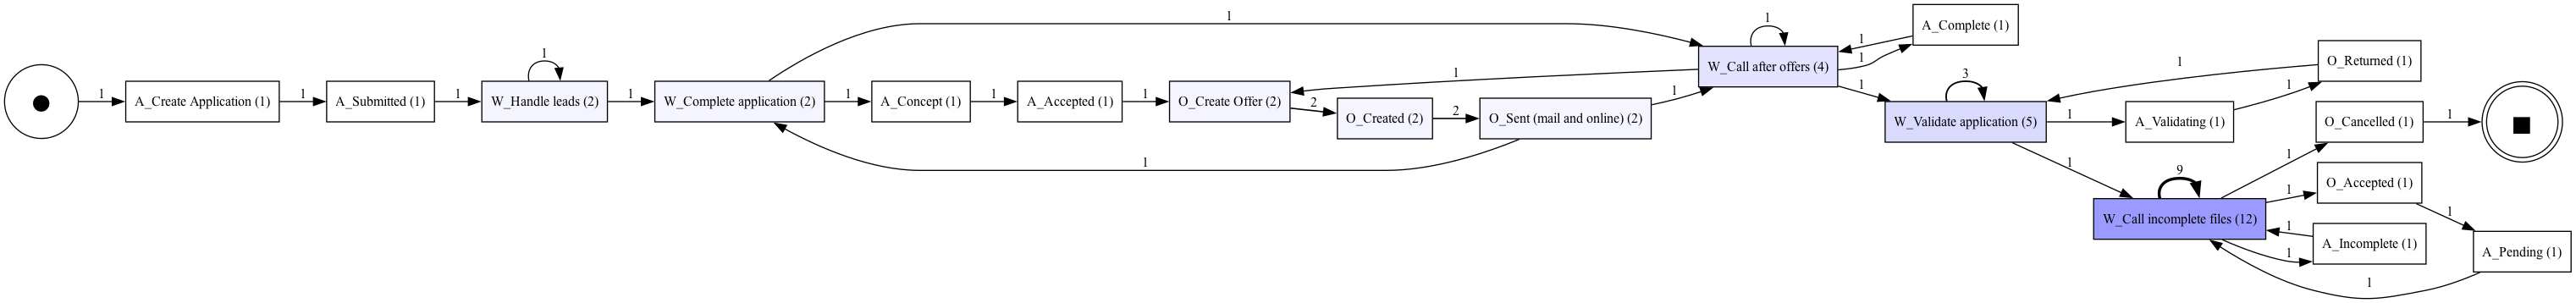

In [11]:
case_list = list(df['case:concept:name'].unique())

df_trace = df[df['case:concept:name'].isin(case_list[:1])]

dfg_trace, start_activities_trace, end_activities_trace = pm4py.discover_dfg(df_trace)

pm4py.view_dfg(
    dfg_trace,
    start_activities_trace,
    end_activities_trace
)

In [12]:
#('A_Create Application', 'A_Submitted') from sequence list
# Example for sequence (< / >):
print("A_Create Application > A_Submitted (Trace):")
print(dfg_trace.get(("A_Create Application", "A_Submitted"), 0))
print(dfg_trace.get(("A_Submitted", "A_Create Application"), 0))
print()
print("A_Create Application > A_Submitted (Complete Log):")
print(dfg.get(("A_Create Application", "A_Submitted"), 0))
print(dfg.get(("A_Submitted", "A_Create Application"), 0))

A_Create Application > A_Submitted (Trace):
1
0

A_Create Application > A_Submitted (Complete Log):
3255
0


In the selected trace, A_Submitted directly follows A_Create Application once, while the reverse direction does not occur.
Therefore, for this trace we observe:

A_Create Application > A_Submitted
A_Submitted ≯ A_Create Application

According to the footprint definition, if a > b and not b > a, then a → b.
Thus, the footprint cell for A_Create Application and A_Submitted is →.

In [13]:
# ('A_Complete', 'W_Call after offers')
# Example for parallel (||):
print("A_Complete || W_Call after offers (Trace):")
print(dfg_trace.get(("A_Complete", "W_Call after offers"), 0))
print(dfg_trace.get(("W_Call after offers", "A_Complete"), 0))
print()
print("A_Complete || W_Call after offers (Complete Log):")
print(dfg.get(("A_Complete", "W_Call after offers"), 0))
print(dfg.get(("W_Call after offers", "A_Complete"), 0))

A_Complete || W_Call after offers (Trace):
1
1

A_Complete || W_Call after offers (Complete Log):
4838
4979


In the clean log, A_Complete directly follows W_Call after offers 4838 times, and W_Call after offers directly follows A_Complete 4979 times.

Since both directly-follows directions occur, both a > b and b > a hold.

According to the footprint definition, this means A_Complete || W_Call after offers.

In [14]:
# get activities from first trace

case_id = case_list[0]

trace_df = df[df["case:concept:name"] == case_id]

trace_activities = trace_df["concept:name"].tolist()

trace_activities

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Complete application',
 'W_Call after offers',
 'W_Call after offers',
 'A_Complete',
 'W_Call after offers',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Call after offers',
 'W_Validate application',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'W_Validate application',
 'W_Validate application',
 'W_Validate application',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'A_Incomplete',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'O_Accepted',
 'A_Pending',
 'W_Call incomplete files',
 'O_Cancelled']

In [15]:
# find activities with no relation
def find_hash_relation_example(dfg, activities):
    for a in activities:
        for b in activities:
            if a == b:
                continue

            if dfg.get((a, b), 0) == 0 and dfg.get((b, a), 0) == 0:
                return a, b

    return None

In [16]:
find_hash_relation_example(dfg_trace, trace_activities)

('A_Create Application', 'W_Handle leads')

In [17]:
# Example for no relation:
print("A_Create Application # W_Handle leads (Trace):")
print(dfg_trace.get(("A_Create Application", "W_Handle leads"), 0))
print(dfg_trace.get(("W_Handle leads", "A_Create Application"), 0))
print()
print("A_Create Application # W_Handle leads (Complete Log):")
print(dfg.get(("A_Create Application", "W_Handle leads"), 0))
print(dfg.get(("W_Handle leads", "A_Create Application"), 0))

A_Create Application # W_Handle leads (Trace):
0
0

A_Create Application # W_Handle leads (Complete Log):
0
0


Neither direction occurs in the clean log.

Therefore, neither A_Create Application > W_Handle leads nor W_Handle leads > A_Create Application holds.

According to the footprint definition, the relation is #.

### 2. Noised Log

In [18]:
footprints_noised = footprints_discovery.apply(log_noised)

In [19]:
footprints_noised["sequence"]

{('A_Acc.', 'O_Create Off.'),
 ('A_Acc.', 'O_Create Offer'),
 ('A_Acc. - Incident No. Application_435753618', 'O_Create Offer'),
 ('A_Acc. - Incident No. Application_562322973', 'O_Create Offer'),
 ('A_Accepted', 'O_Create Off.'),
 ('A_Accepted', 'O_Create Offer'),
 ('A_Accepted', 'O_Create Offer - Incident No. Application_1850936258'),
 ('A_Accepted', 'O_Create Offer - Incident No. Application_2066286284'),
 ('A_Accepted', 'O_Create Offer - Incident No. Application_342000872'),
 ('A_Accepted - Incident No. Application_1232536865', 'O_Create Offer'),
 ('A_Accepted - Incident No. Application_156712942', 'O_Create Offer'),
 ('A_Accepted - Incident No. Application_2055100599', 'O_Create Offer'),
 ('A_Accepted - Incident No. Application_54309881', 'O_Create Offer'),
 ('A_Canc.', 'O_Canc.'),
 ('A_Canc.', 'O_Cancelled'),
 ('A_Cancelled', 'O_Cancelled - Incident No. Application_147352520'),
 ('A_Cancelled', 'O_Cancelled - Incident No. Application_389383837'),
 ('A_Cancelled', 'O_Cancelled - I

In [20]:
footprints_noised["parallel"]

{('A_Acc.', 'W_Complete application'),
 ('A_Acc.', 'W_Finalize application'),
 ('A_Acc.', 'W_Finish application'),
 ('A_Accepted', 'W_Complete appl.'),
 ('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Finalize application'),
 ('A_Accepted', 'W_Finish application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Cancelled', 'O_Canc.'),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call after ofrs.'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Comp.', 'W_Call after offers'),
 ('A_Comp.', 'W_Call after ofrs.'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Complete', 'W_Call after ofrs.'),
 ('A_Complete - Incident No. Application_1224580155', 'W_Call after offers'),
 ('A_Complete - Incident No. Application_1369571234', 'W_Call after offers'),
 ('A_Complete - Incident No. Application_1371149184', 'W_Call after offers'),
 ('A_Complete - Incident No. Application_1396568513', 'W_Ca

In [21]:
gviz_footprints_noised = fp_visualizer.apply(footprints_noised)
fp_visualizer.view(gviz_footprints_noised)
gviz_footprints_noised.format = "svg"
gviz_footprints_noised.render(
    filename="../data/milestone2/footprints_noised",
    cleanup=True
)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.427422 to fit


'../data/milestone2/footprints_noised.svg'

#### Specific Trace

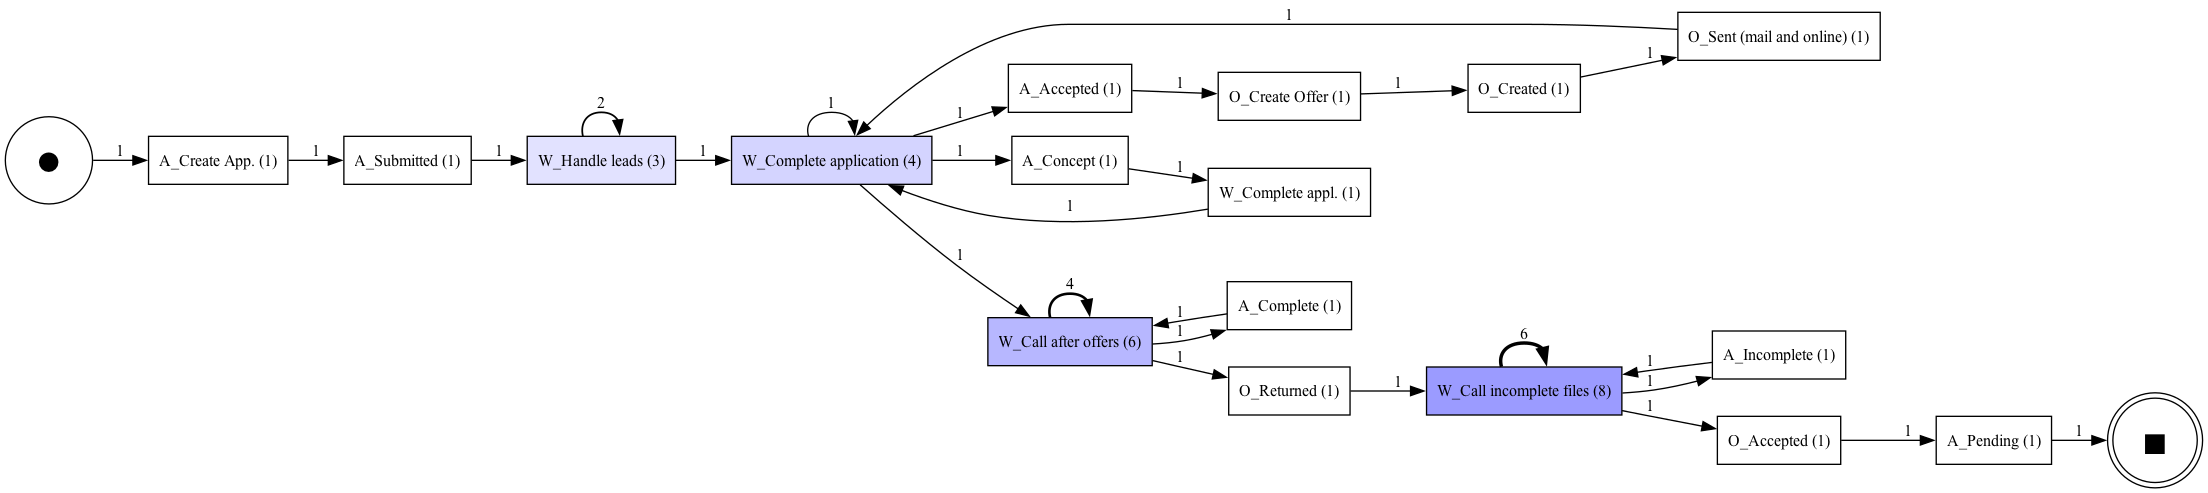

In [22]:
case_list_noised = list(df_noised['case:concept:name'].unique())

df_noised_trace = df_noised[
    df_noised['case:concept:name'].isin(case_list_noised[:1])
]

dfg_trace_noised, start_activities_trace_noised, end_activities_trace_noised = pm4py.discover_dfg(df_noised_trace)

pm4py.view_dfg(
    dfg_trace_noised,
    start_activities_trace_noised,
    end_activities_trace_noised
)

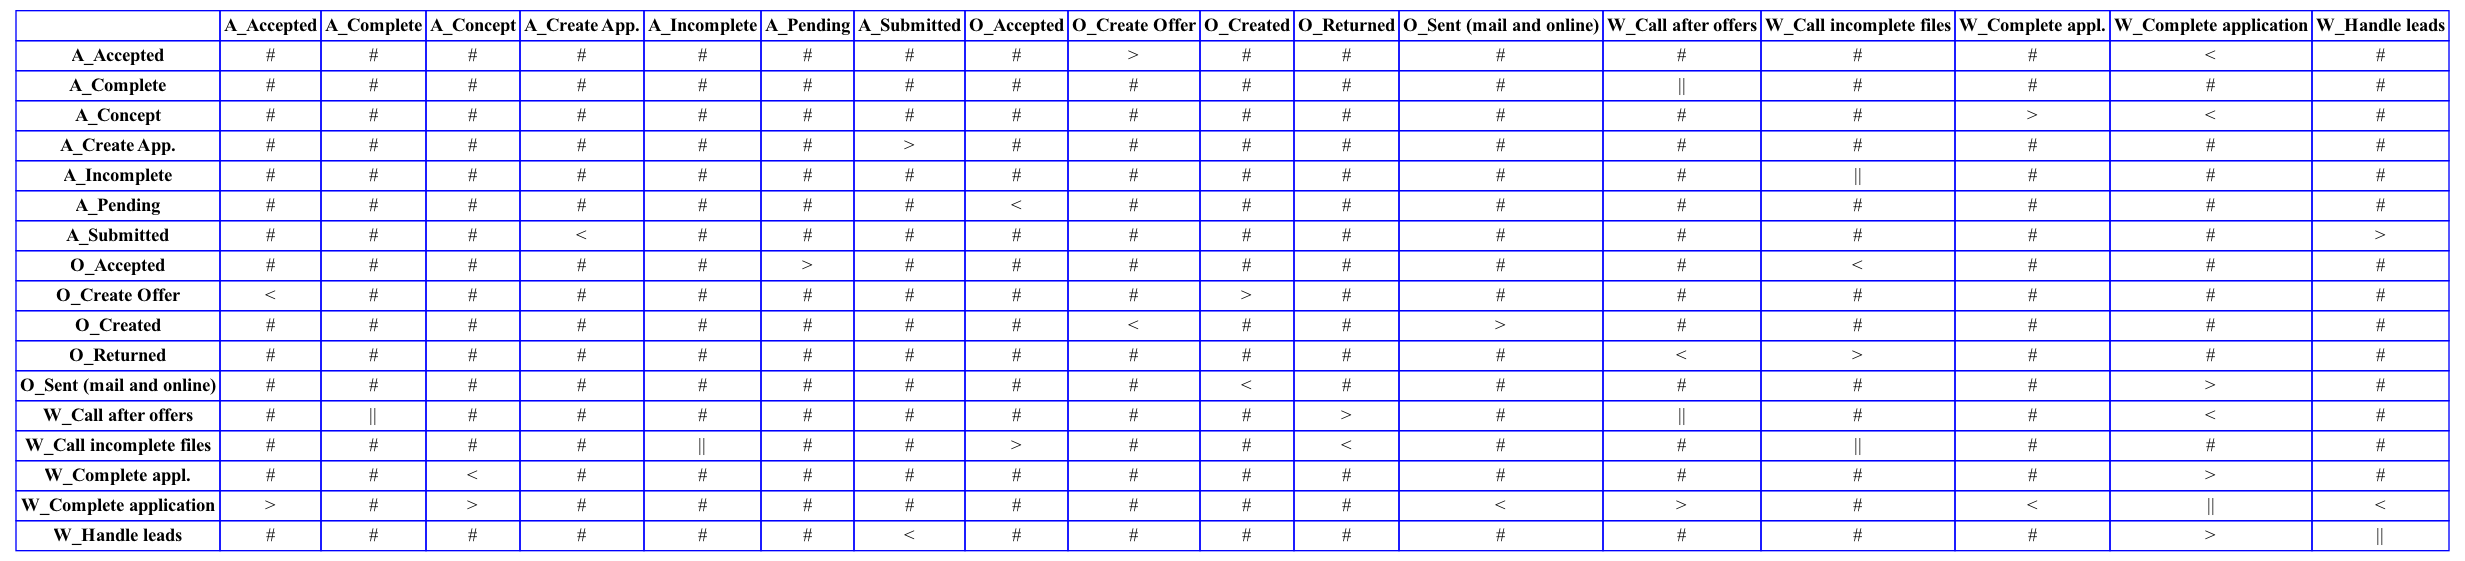

In [23]:
footprints_trace_noised = footprints_discovery.apply(df_noised_trace)

# Because the complete footprint matrix of the noised log is very large and visually dense, we additionally inspect the footprint of one selected trace to justify selected relations more clearly.

gviz_footprints_trace_noised = fp_visualizer.apply(footprints_trace_noised)
fp_visualizer.view(gviz_footprints_trace_noised)

In [24]:
#('A_Create Application', 'A_Submitted') from sequence list
# Example for sequence (< / >):
print("A_Create App. > A_Submitted (Trace):")
print(dfg_trace_noised.get(("A_Create App.", "A_Submitted"), 0))
print(dfg_trace_noised.get(("A_Submitted", "A_Create App."), 0))
print()
print("A_Create App. > A_Submitted (Complete Log):")
print(dfg_noised.get(("A_Create App.", "A_Submitted"), 0))
print(dfg_noised.get(("A_Submitted", "A_Create App."), 0))

A_Create App. > A_Submitted (Trace):
1
0

A_Create App. > A_Submitted (Complete Log):
150
0


In the selected trace, A_Submitted directly follows A_Create App. once, while the reverse direction does not occur.
Therefore, for this trace we observe:

A_Create App. > A_Submitted
A_Submitted ≯ A_Create App.

According to the footprint definition, if a > b and not b > a, then a → b.
Thus, the footprint cell for A_Create Application and A_Submitted is →.

In [25]:
# ('A_Complete', 'W_Call after offers')
# Example for parallel (||):
print("A_Complete || W_Call after offers (Trace):")
print(dfg_trace_noised.get(("A_Complete", "W_Call after offers"), 0))
print(dfg_trace_noised.get(("W_Call after offers", "A_Complete"), 0))
print()
print("A_Complete || W_Call after offers (Complete Log):")
print(dfg_noised.get(("A_Complete", "W_Call after offers"), 0))
print(dfg_noised.get(("W_Call after offers", "A_Complete"), 0))

A_Complete || W_Call after offers (Trace):
1
1

A_Complete || W_Call after offers (Complete Log):
4383
4518


In the noised log, A_Complete directly follows W_Call after offers 4383 times, and W_Call after offers directly follows A_Complete 4518 times.

Since both directly-follows directions occur, both a > b and b > a hold.

According to the footprint definition, this means A_Complete || W_Call after offers.

In [26]:
# Get activities from first trace

case_id_noised = case_list_noised[0]

trace_df_noised = df_noised[df_noised["case:concept:name"] == case_id_noised]

trace_activities_noised = trace_df_noised["concept:name"].unique().tolist()

trace_activities_noised

['A_Create App.',
 'A_Submitted',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'W_Complete appl.',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Call after offers',
 'A_Complete',
 'O_Returned',
 'W_Call incomplete files',
 'A_Incomplete',
 'O_Accepted',
 'A_Pending']

In [27]:
# Find activities with no relation
find_hash_relation_example(dfg_trace_noised, trace_activities_noised)

('A_Create App.', 'W_Handle leads')

In [28]:
# Example for no relation:
print("A_Create App. # W_Handle leads (Trace):")
print(dfg_trace_noised.get(("A_Create App.", "W_Handle leads"),0))
print(dfg_trace_noised.get(("W_Handle leads", "A_Create App."),0))
print("A_Create App. # W_Handle leads (Complete Log):")
print(dfg_noised.get(("A_Create App.", "W_Handle leads"),0))
print(dfg_noised.get(("W_Handle leads", "A_Create App."),0))

A_Create App. # W_Handle leads (Trace):
0
0
A_Create App. # W_Handle leads (Complete Log):
0
0


Neither direction occurs in the noised log.

Therefore, neither A_Create App. > W_Handle leads nor W_Handle leads > A_Create App. holds.

According to the footprint definition, the relation is #.

### 3. Recovered Log

In [29]:
footprints_recovered = footprints_discovery.apply(log_recovered)

In [30]:
footprints_recovered["sequence"]

{('A_Accepted', 'O_Create Offer'),
 ('A_Concept', 'A_Accepted'),
 ('A_Create Application', 'A_Submitted'),
 ('A_Create Application', 'W_Complete application'),
 ('A_Denied', 'O_Refused'),
 ('A_Submitted', 'W_Handle leads'),
 ('A_Validating', 'A_Denied'),
 ('A_Validating', 'A_Incomplete'),
 ('A_Validating', 'A_Pending'),
 ('A_Validating', 'O_Returned'),
 ('O_Cancelled', 'A_Complete'),
 ('O_Cancelled', 'A_Denied'),
 ('O_Cancelled', 'A_Incomplete'),
 ('O_Cancelled', 'O_Create Offer'),
 ('O_Cancelled', 'O_Returned'),
 ('O_Created', 'A_Cancelled'),
 ('O_Created', 'A_Complete'),
 ('O_Created', 'A_Denied'),
 ('O_Created', 'A_Incomplete'),
 ('O_Created', 'O_Cancelled'),
 ('O_Created', 'O_Sent (mail and online)'),
 ('O_Created', 'O_Sent (online only)'),
 ('O_Created', 'W_Call after offers'),
 ('O_Created', 'W_Call incomplete files'),
 ('O_Created', 'W_Complete application'),
 ('O_Refused', 'W_Assess potential fraud'),
 ('O_Refused', 'W_Call after offers'),
 ('O_Refused', 'W_Call incomplete file

In [31]:
footprints_recovered["parallel"]

{('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Shortened completion'),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Validate application'),
 ('A_Complete', 'O_Sent (mail and online)'),
 ('A_Complete', 'O_Sent (online only)'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Complete', 'W_Complete application'),
 ('A_Concept', 'A_Create Application'),
 ('A_Concept', 'W_Complete application'),
 ('A_Concept', 'W_Handle leads'),
 ('A_Create Application', 'A_Concept'),
 ('A_Denied', 'W_Call after offers'),
 ('A_Denied', 'W_Call incomplete files'),
 ('A_Denied', 'W_Complete application'),
 ('A_Denied', 'W_Validate application'),
 ('A_Incomplete', 'O_Returned'),
 ('A_Incomplete', 'W_Call incomplete files'),
 ('A_Incomplete', 'W_Validate application'),
 ('A_Pending', 'O_Accepted'),
 ('A_Pending', 'W_Call incomplete files'),
 ('A_Pending', 'W_Valid

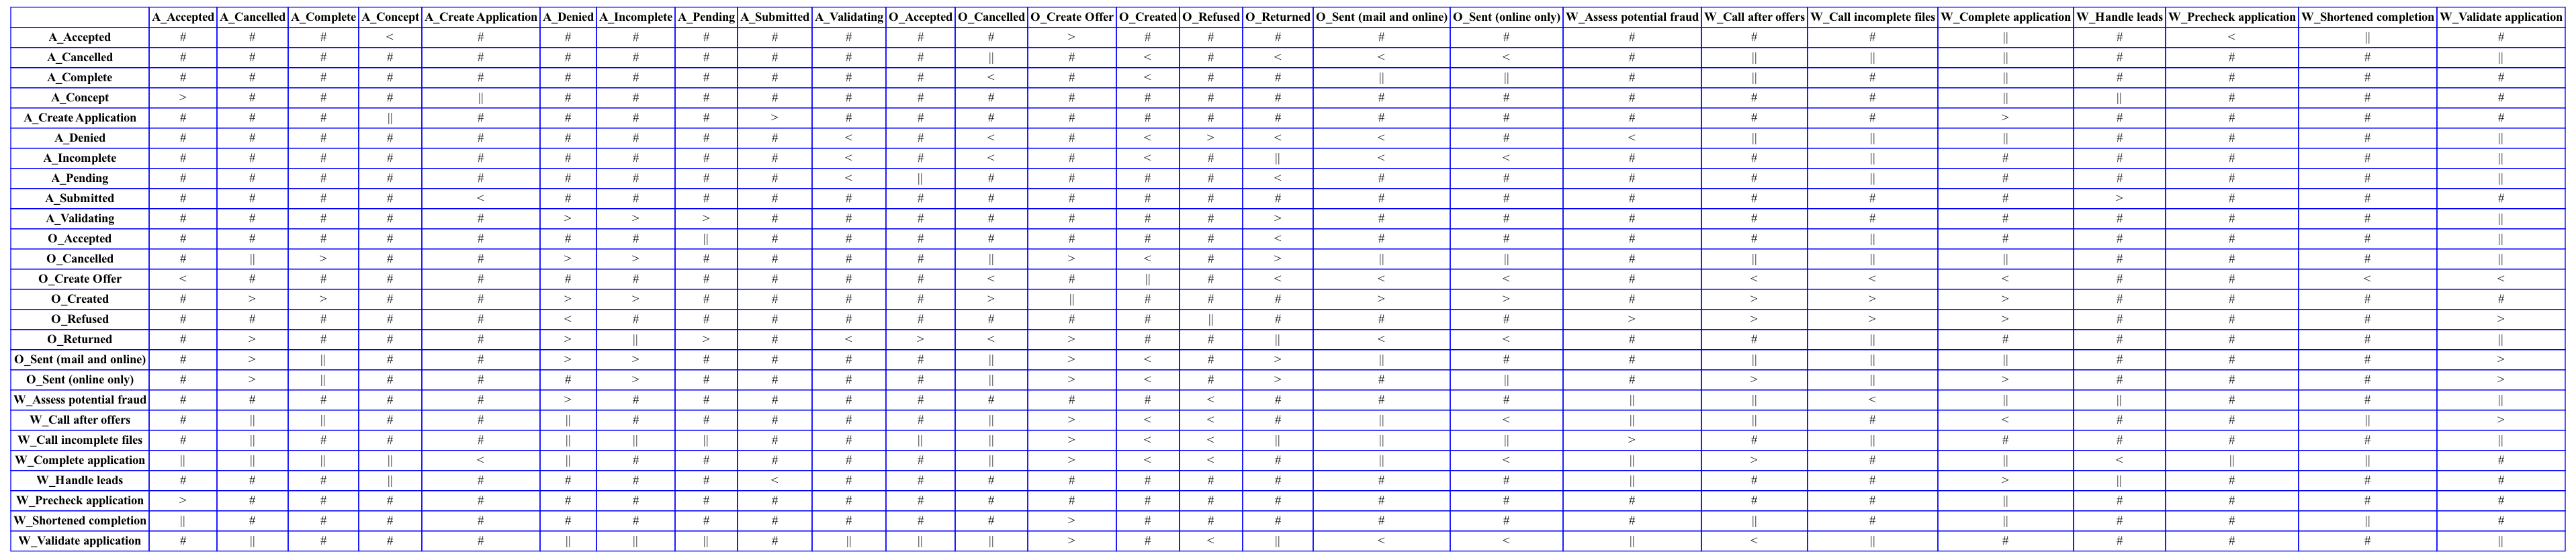

'../data/milestone2/footprints_recovered.svg'

In [32]:
gviz_footprints_recovered = fp_visualizer.apply(footprints_recovered)
fp_visualizer.view(gviz_footprints_recovered)
gviz_footprints_recovered.format = "svg"
(gviz_footprints_recovered.render(
    filename="../data/milestone2/footprints_recovered",
    cleanup=True
))

#### Specific Trace

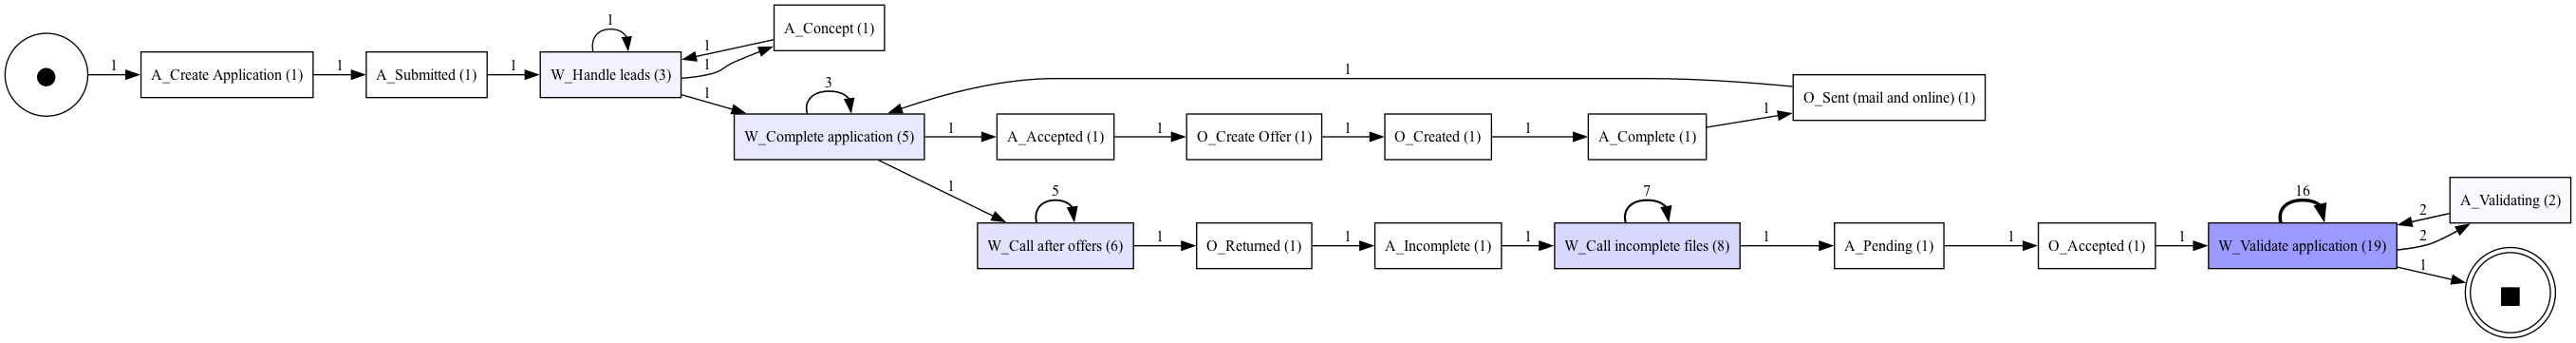

In [33]:
case_list_recovered = list(df_recovered['case:concept:name'].unique())

df_recovered_trace = df_recovered[
    df_recovered['case:concept:name'].isin(case_list_recovered[:1])
]

dfg_trace_recovered, start_activities_trace_recovered, end_activities_trace_recovered = pm4py.discover_dfg(df_recovered_trace)

pm4py.view_dfg(
    dfg_trace_recovered,
    start_activities_trace_recovered,
    end_activities_trace_recovered
)

In [34]:
#('A_Create Application', 'A_Submitted') from sequence list
# Example for sequence (< / >):
print("A_Create Application > A_Submitted (Trace):")
print(dfg_trace_recovered.get(("A_Create Application", "A_Submitted"), 0))
print(dfg_trace_recovered.get(("A_Submitted", "A_Create Application"), 0))
print()
print("A_Create Application > A_Submitted (Complete Log):")
print(dfg_recovered.get(("A_Create Application", "A_Submitted"), 0))
print(dfg_recovered.get(("A_Submitted", "A_Create Application"), 0))

A_Create Application > A_Submitted (Trace):
1
0

A_Create Application > A_Submitted (Complete Log):
3255
0


In the selected trace, A_Submitted directly follows A_Create Application once, while the reverse direction does not occur.
Therefore, for this trace we observe:

A_Create Application > A_Submitted
A_Submitted ≯ A_Create Application

According to the footprint definition, if a > b and not b > a, then a → b.
Thus, the footprint cell for A_Create Application and A_Submitted is →.

In [35]:
# ('A_Complete', 'W_Call after offers')
# Example for parallel (||):
print("A_Concept || W_Handle leads (Trace):")
print(dfg_trace_recovered.get(("A_Concept", "W_Handle leads"), 0))
print(dfg_trace_recovered.get(("W_Handle leads", "A_Concept"), 0))
print("A_Concept || W_Handle leads (Complete Log):")
print(dfg_recovered.get(("A_Concept", "W_Handle leads"), 0))
print(dfg_recovered.get(("W_Handle leads", "A_Concept"), 0))

A_Concept || W_Handle leads (Trace):
1
1
A_Concept || W_Handle leads (Complete Log):
3186
3227


In the recovered log, A_Concept directly follows W_Handle leads 3186 times, and W_Handle leads directly follows A_Concept 3227 times.

Since both directly-follows directions occur, both a > b and b > a hold.

According to the footprint definition, this means A_Concept || W_Handle leads.

In [36]:
# get activities from first trace

case_id_recovered = case_list_recovered[0]

trace_df_recovered = df_recovered[df_recovered["case:concept:name"] == case_id_recovered]

trace_activities_recovered = trace_df_recovered["concept:name"].unique().tolist()

trace_activities_recovered

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'A_Concept',
 'W_Complete application',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'A_Complete',
 'O_Sent (mail and online)',
 'W_Call after offers',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'A_Incomplete',
 'W_Call incomplete files',
 'A_Pending',
 'O_Accepted']

In [37]:
# Find activities with no relation
find_hash_relation_example(dfg_trace_recovered, trace_activities_recovered)

('A_Create Application', 'W_Handle leads')

In [38]:
# Example for no relation:
print("A_Create Application # W_Handle leads (Trace):")
print(dfg_trace_recovered.get(("A_Create Application", "W_Handle leads"),0))
print(dfg_trace_recovered.get(("W_Handle leads", "A_Create Application"),0))
print()
print("A_Create Application # W_Handle leads (Complete):")
print(dfg_recovered.get(("A_Create Application", "W_Handle leads"),0))
print(dfg_recovered.get(("W_Handle leads", "A_Create Application"),0))

A_Create Application # W_Handle leads (Trace):
0
0

A_Create Application # W_Handle leads (Complete):
0
0


Neither direction occurs in the recovered log.
Therefore, neither A_Create Application > W_Handle leads nor W_Handle leads > A_Create Application holds.
According to the footprint definition, the relation is #.

## b) alpha-miner

In [39]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

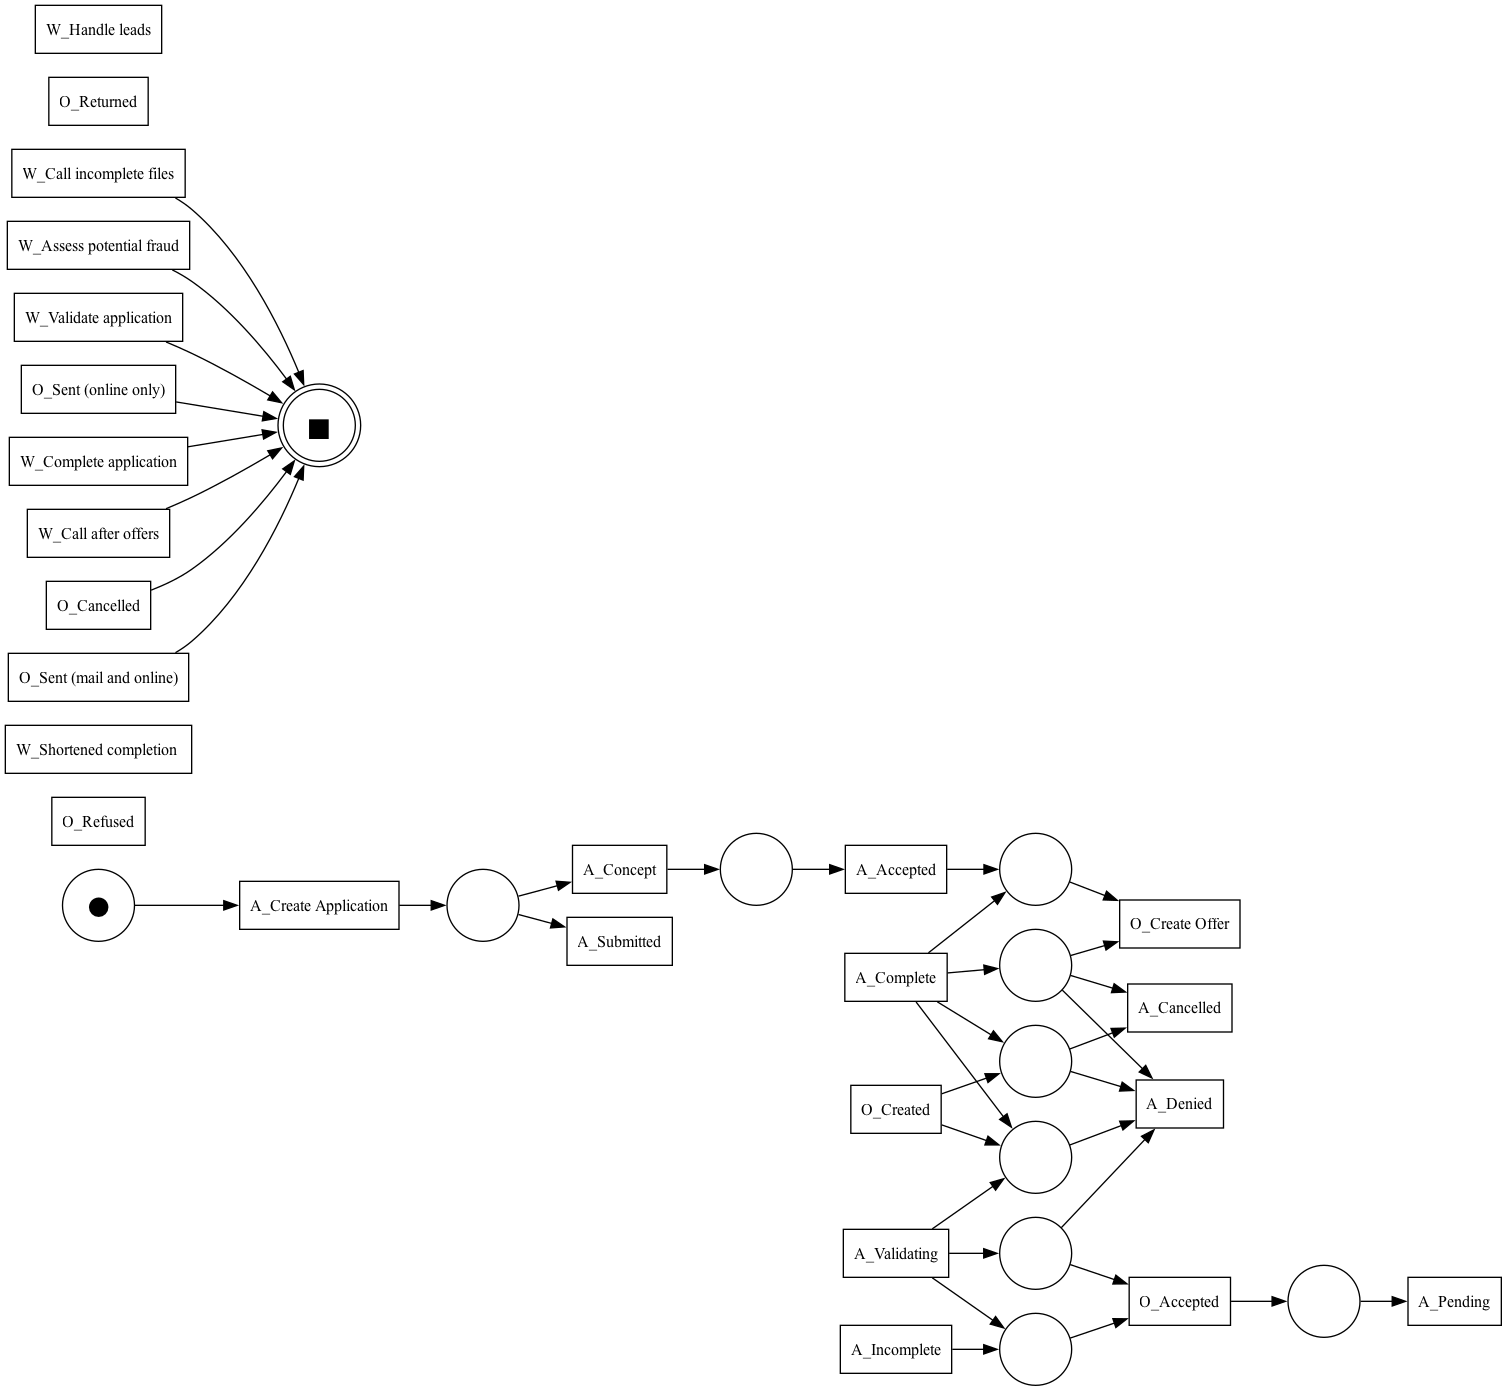

'../data/milestone2/petri_net_clean.svg'

In [40]:
net_clean, initial_marking_clean, final_marking_clean = alpha_miner.apply(log)

gviz_net_clean = pn_visualizer.apply(
    net_clean,
    initial_marking_clean,
    final_marking_clean
)

pn_visualizer.view(gviz_net_clean)

gviz_net_clean.format = "svg"
gviz_net_clean.render(
    filename="../data/milestone2/petri_net_clean",
    cleanup=True
)

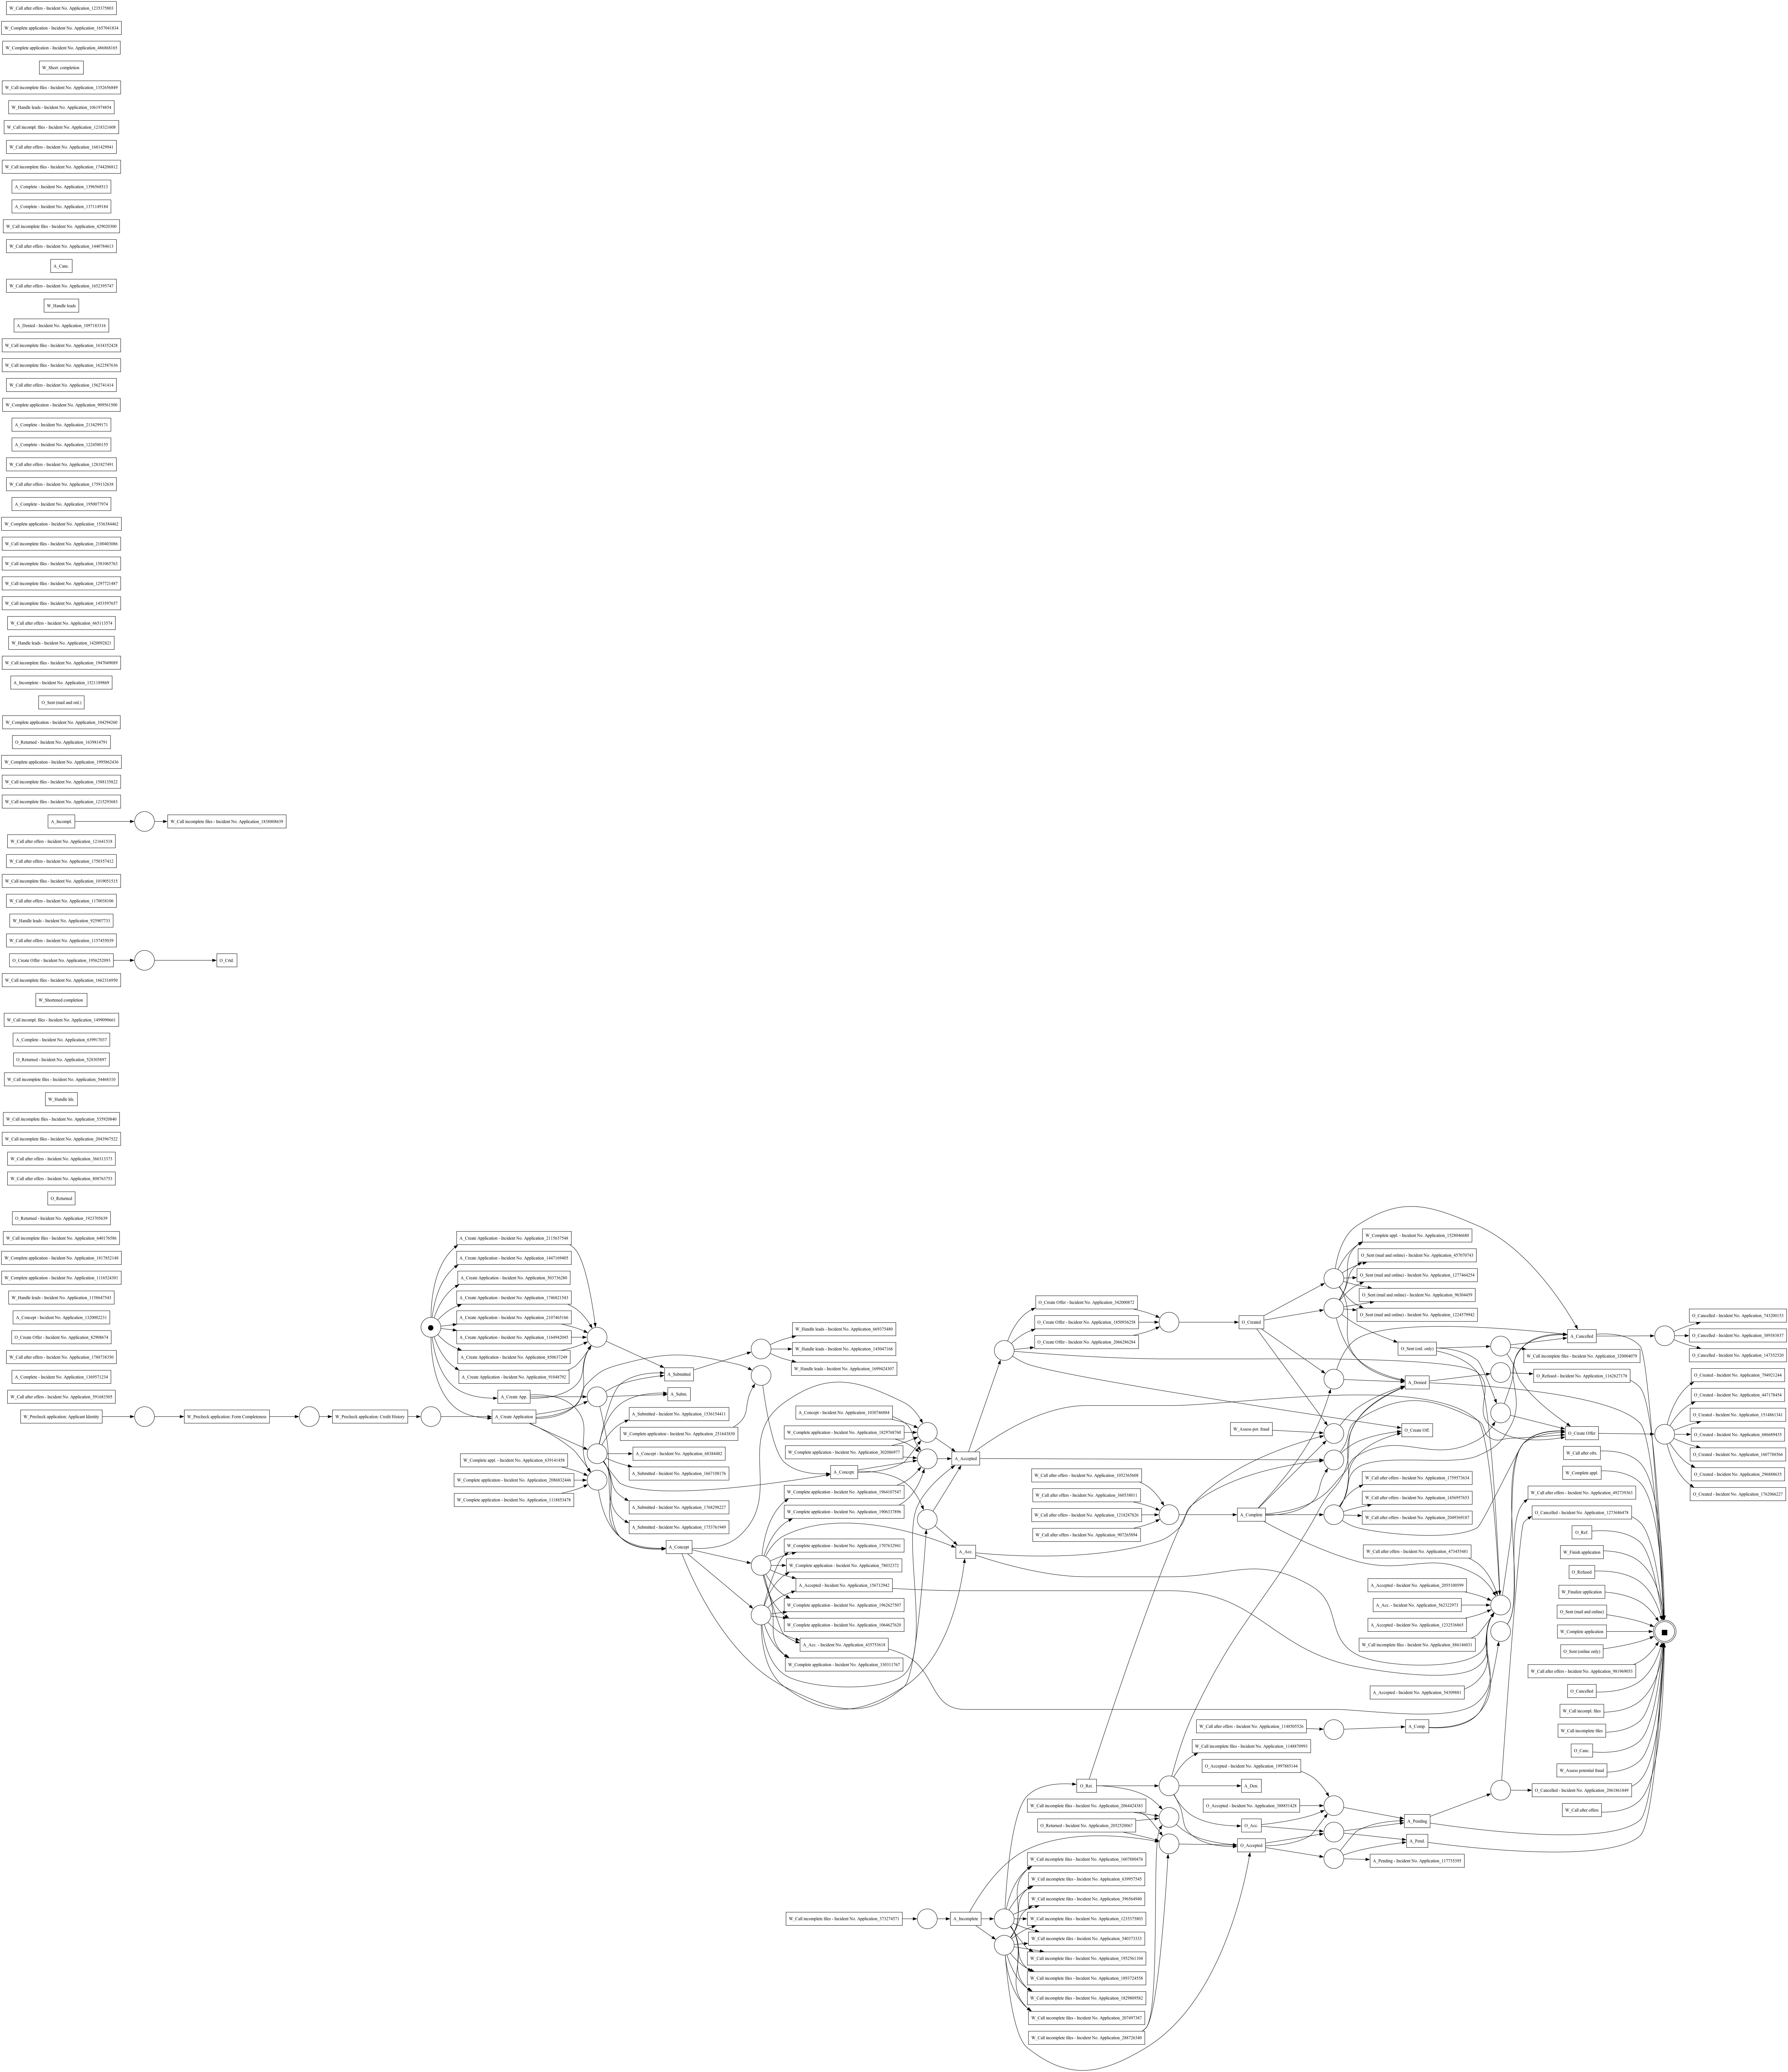

'../data/milestone2/petri_net_noised.svg'

In [41]:
net_noised, initial_marking_noised, final_marking_noised = alpha_miner.apply(df_noised)

gviz_net_noised = pn_visualizer.apply(
    net_noised,
    initial_marking_noised,
    final_marking_noised
)

pn_visualizer.view(gviz_net_noised)

gviz_net_noised.format = "svg"
gviz_net_noised.render(
    filename="../data/milestone2/petri_net_noised",
    cleanup=True
)

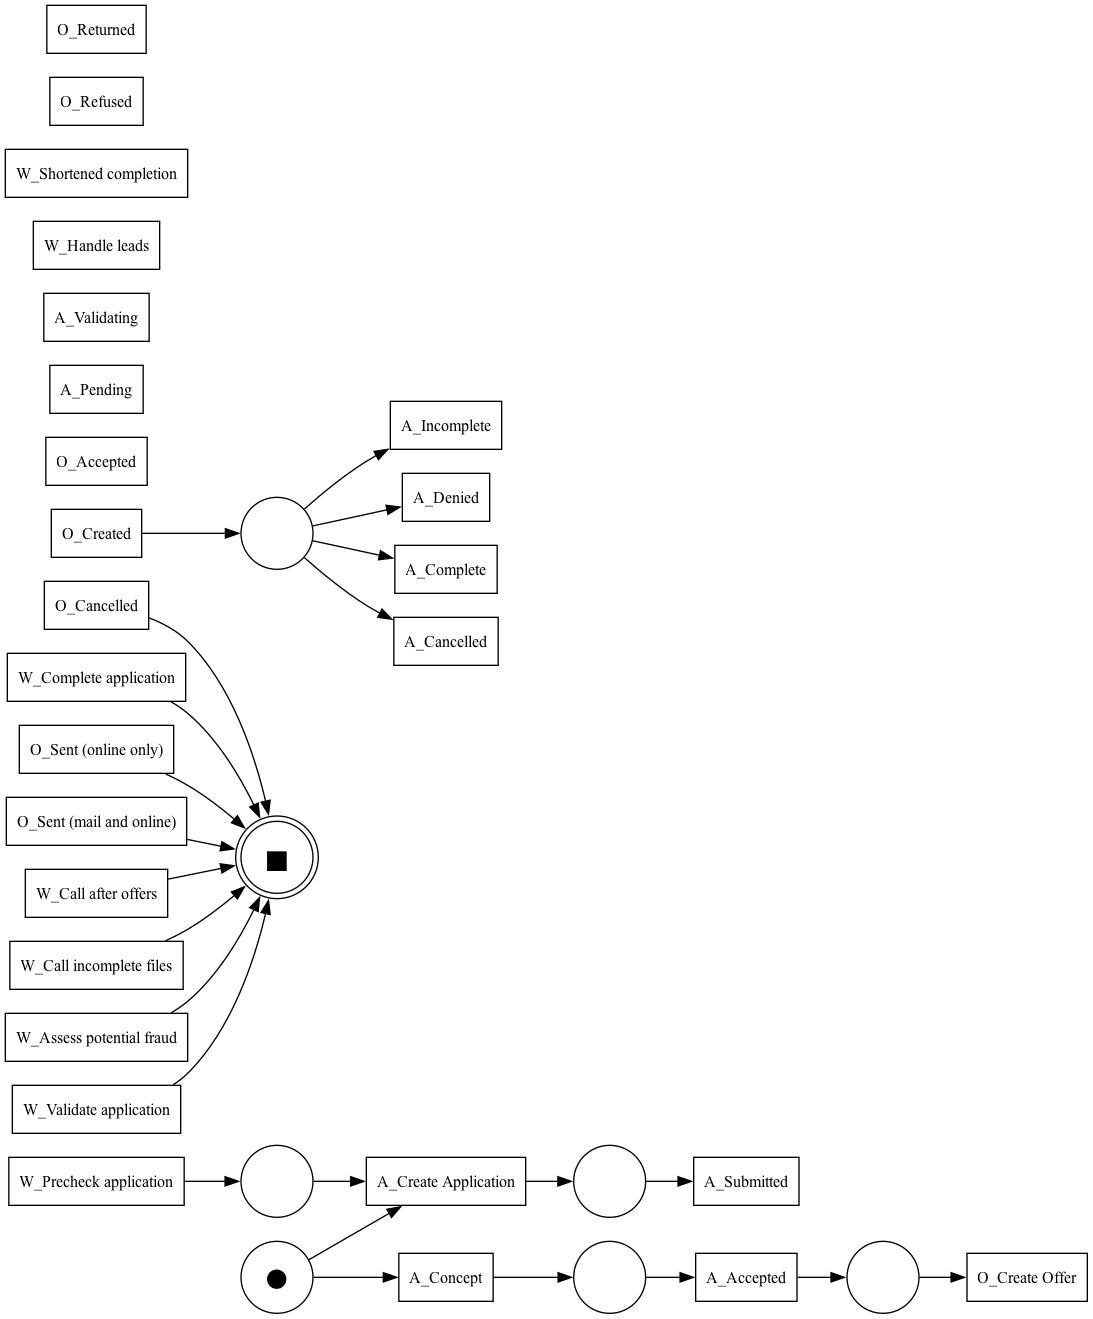

'../data/milestone2/petri_net_recovered.svg'

In [42]:
net_recovered, initial_marking_recovered, final_marking_recovered = alpha_miner.apply(log_recovered)

gviz_net_recovered = pn_visualizer.apply(
    net_recovered,
    initial_marking_recovered,
    final_marking_recovered
)

pn_visualizer.view(gviz_net_recovered)

gviz_net_recovered.format = "svg"
gviz_net_recovered.render(
    filename="../data/milestone2/petri_net_recovered",
    cleanup=True
)

In [43]:
print("Clean sample cases:", df["case:concept:name"].nunique())
print("Noised sample cases:", df_noised["case:concept:name"].nunique())
print("Recovered sample cases:", df_recovered["case:concept:name"].nunique())

print("Clean activities:", df["concept:name"].nunique())
print("Noised activities:", df_noised["concept:name"].nunique())
print("Recovered activities:", df_recovered["concept:name"].nunique())

Clean sample cases: 5000
Noised sample cases: 5000
Recovered sample cases: 5000
Clean activities: 25
Noised activities: 202
Recovered activities: 26


In [44]:
def evaluate_model(log, net, initial_marking, final_marking, name):
    fitness = replay_fitness_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking,
        variant=replay_fitness_evaluator.Variants.TOKEN_BASED
    )

    precision = precision_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking
    )

    generalization = generalization_evaluator.apply(
        log,
        net,
        initial_marking,
        final_marking
    )

    simplicity = simplicity_evaluator.apply(net)

    return {
        "model": name,
        "fitness": fitness,
        "precision": precision,
        "generalization": generalization,
        "simplicity": simplicity,
        "places": len(net.places),
        "transitions": len(net.transitions),
        "arcs": len(net.arcs)
    }

In [45]:
results = [
    evaluate_model(
        df,
        net_clean,
        initial_marking_clean,
        final_marking_clean,
        "Clean"
    ),
    evaluate_model(
        df_noised,
        net_noised,
        initial_marking_noised,
        final_marking_noised,
        "Noised"
    ),
    evaluate_model(
        df_recovered,
        net_recovered,
        initial_marking_recovered,
        final_marking_recovered,
        "Recovered"
    )
]

replaying log with TBR, completed traces ::   0%|          | 0/3132 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/54971 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3132 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4745 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/85263 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4745 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3207 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/57491 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3207 [00:00<?, ?it/s]

In [46]:
results_df = pd.DataFrame([
    {
        "Model": r["model"],
        "Fitness": r["fitness"]["log_fitness"],
        "Precision": r["precision"],
        "Generalization": r["generalization"],
        "Simplicity": r["simplicity"],
        "Places": r["places"],
        "Transitions": r["transitions"],
        "Arcs": r["arcs"]
    }
    for r in results
])

results_df.round(3)

,Model,Fitness,Precision,Generalization,Simplicity,Places,Transitions,Arcs
0,Clean,0.498,0.095,0.976,0.947,11,25,37
1,Noised,0.432,0.071,0.226,0.855,45,202,268
2,Recovered,0.419,0.056,0.954,1.000,7,26,23


In [47]:
print("Clean DFG edges:", len(dfg))
print("Recovered DFG edges:", len(dfg_recovered))

Clean DFG edges: 149
Recovered DFG edges: 158


### Explanation of results

In [48]:
print("Clean sequence:", len(footprints["sequence"]))
print("Noised sequence:", len(footprints_noised["sequence"]))
print("Recovered sequence:", len(footprints_recovered["sequence"]))

print("Clean parallel:", len(footprints["parallel"]))
print("Noised parallel:", len(footprints_noised["parallel"]))
print("Recovered parallel:", len(footprints_recovered["parallel"]))

Clean sequence: 65
Noised sequence: 439
Recovered sequence: 59
Clean parallel: 84
Noised parallel: 254
Recovered parallel: 108


In [49]:
clean_seq = footprints["sequence"]
noised_seq = footprints_noised["sequence"]
recovered_seq = footprints_recovered["sequence"]

clean_par = footprints["parallel"]
noised_par = footprints_noised["parallel"]
recovered_par = footprints_recovered["parallel"]

print("Noised added sequence relations:")
print(list(noised_seq - clean_seq)[:20])

print("Recovered removed noised sequence relations:")
print(list(noised_seq - recovered_seq)[:20])

print("Recovered missing clean sequence relations:")
print(list(clean_seq - recovered_seq)[:20])

print("Noised added parallel relations:")
print(list(noised_par - clean_par)[:20])

print("Recovered added parallel relations:")
print(list(recovered_par - clean_par)[:20])

Noised added sequence relations:
[('W_Complete appl.', 'A_Accepted - Incident No. Application_2055100599'), ('O_Accepted', 'A_Pending - Incident No. Application_117735395'), ('A_Concept - Incident No. Application_68384482', 'W_Complete application'), ('O_Sent (online only)', 'W_Finish application'), ('W_Call after offers', 'W_Call after offers - Incident No. Application_360538011'), ('A_Acc. - Incident No. Application_435753618', 'O_Create Offer'), ('O_Created', 'O_Sent (mail and online) - Incident No. Application_1224579942'), ('W_Finish application', 'O_Create Offer'), ('W_Call incompl. files', 'A_Den.'), ('O_Returned', 'A_Den.'), ('W_Call after offers - Incident No. Application_1218287826', 'A_Complete'), ('O_Ref.', 'W_Assess potential fraud'), ('W_Call incomplete files - Incident No. Application_1235375803', 'W_Call incomplete files'), ('W_Complete application', 'W_Assess potential fraud'), ('W_Assess potential fraud', 'O_Accepted'), ('W_Finalize application', 'O_Create Off.'), ('A

The evaluation shows that the noised log strongly distorts the alpha-Miner result. Compared to the clean model, the noised model becomes much larger: the number of transitions increases from 25 to 202, the number of places from 11 to 45, and the number of arcs from 37 to 268. This structural growth is caused by polluted and distorted activity labels. Examples include shortened labels such as "A_Acc." and "W_Handle lds.", as well as activity names extended with "Incident No. Application".

This effect is directly visible in the noised footprint matrix. For example, the matrix contains artificial sequence relations such as A_Create Application → A_Subm. and A_Create App. → W_Complete appl. These cells do not represent relations between the original clean process activities. Instead, they are created by shortened or distorted label variants. Similarly, relations involving labels such as W_Call incomplete files - Incident No. Application_886146031 show that activity names with appended incident information are treated as separate activities.

As a result, the noised footprint matrix contains many additional sequence, choice, and parallel relations that are artifacts of data pollution rather than meaningful process behavior. Since the alpha-Algorithm treats every distinct label as a separate activity and does not filter infrequent or noisy behavior, these artificial footprint cells influence the construction of causal, parallel, and choice relations in the mined Petri net. This explains why the noised model is much larger and less reliable than the clean model. It also explains the decrease in precision from 0.095 to 0.071 and, more strongly, the decrease in generalization from 0.976 to 0.226.

The recovered log removes many of these artificial variants. This is visible in the number of transitions, which decreases from 202 in the noised model to 26 in the recovered model, close to the 25 transitions of the clean model. Consequently, generalization improves strongly from 0.226 to 0.954, almost reaching the clean model's value of 0.976. This suggests that the recovery step successfully normalizes many polluted and distorted activity labels. For example, core relations such as A_Create Application → A_Submitted are preserved in the recovered footprint matrix: A_Submitted directly follows A_Create Application, while the reverse relation does not occur.

However, the recovered model is not identical to the clean model. Although the number of transitions is almost restored, the recovered model has fewer places and arcs than the clean model: 7 places and 23 arcs compared to 11 places and 37 arcs in the clean model. This indicates that the recovered footprint matrix does not fully reconstruct the original causal structure. For example, relations such as A_Concept || W_Handle leads show that both directly-follows directions occur. The alpha-Algorithm interprets this as parallelism, even though such behavior may also be caused by loops, repeated activities, or noisy ordering. Similarly, if a relation that was causal in the clean footprint becomes parallel or choice-like after recovery, it can no longer be used in the same way to construct places.

Fitness measures how much of the observed log behavior can be replayed by the mined model. The clean model already has limited fitness, which indicates that the alpha-Algorithm does not capture all behavior in the original log. This is consistent with known alpha-Algorithm limitations, especially its problems with loops, duplicate activities, non-free-choice constructs, and complex parallel behavior. The recovered model has even lower fitness, decreasing from 0.498 to 0.419, meaning that some behavior in the recovered log cannot be replayed by the simplified recovered model.

Precision measures how much additional behavior the model allows beyond the log. The low precision values show that all discovered models allow much more behavior than actually observed. This is especially visible when footprint cells are classified as parallel, such as A_Concept || W_Handle leads, because parallel relations allow many possible interleavings. The recovered model's precision decreases to 0.056, which suggests that although the model is smaller, it still allows behavior not observed in the log.

This also explains why the recovered model is structurally simpler but not necessarily better in all quality dimensions. The alpha-Miner does not translate DFG edges directly into Petri-net arcs. It first classifies footprint relations into causality, parallelism, and choice. Only clear causal relations are used to construct places and arcs. If the recovered footprint contains fewer usable causal relations than the clean footprint, the alpha-Miner creates fewer places and arcs. This leads to a very high simplicity value of 1.000, but it also explains why fitness and precision remain below the clean model.

Overall, the recovered model is clearly closer to the clean model than the noised model in terms of structural size and generalization. The noised model strongly overfits to artificial activity variants, while the recovered model removes most of them. However, the recovered model does not fully restore the clean process behavior. This is consistent with the known limitations of the alpha-Algorithm: it is sensitive to noise, cannot filter rare behavior, and struggles with loops, non-free-choice constructs, and complex parallel behavior.